# Vision-Based Traffic Flow Prediction Using YOLOv8 and LSTM
## Notebook 10: GRU Forecasting Comparison (Phase 10)

### Phase 10 Objective & Scope
In Phase 9, we developed and evaluated our first recurrent neural network: a compact Long Short-Term Memory (LSTM) model.

In **Phase 10**, we implement a **controlled Gated Recurrent Unit (GRU) comparison** to the Phase 9 LSTM under identical experimental conditions:
1. **Identical Slicing & Partitions**: Exact same Phase 7 Target-Anchored protocol ($17$ train, $3$ validation, $2$ test windows).
2. **Identical Horizon Formulation**: Lookback $L = 10 \to$ multi-step forecast horizon $H = 5$ (`total_vehicle_count`).
3. **Identical Preprocessing**: Same `StandardScaler` fitted strictly on training data ($\mu = 8.7512, \sigma = 4.5703$) and applied out-of-sample.
4. **Matched Architecture**:
   - Single recurrent layer with **$16$ hidden units** (`batch_first=True`).
   - Dropout ($p = 0.10$) on the final hidden representation.
   - Linear output projection to $H = 5$ horizons.
5. **Identical Training & Optimization**:
   - Adam optimizer with $\text{lr} = 0.001$, $\text{weight\_decay} = 10^{-4}$.
   - MSE Loss, max $150$ epochs, early stopping patience $= 25$ on validation loss.
   - Test partition kept completely untouched until final evaluation.
6. **Empirical Honesty**: Do not claim GRU superiority unless measured results support it. Compare directly against LSTM and Phase 8 baselines.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# Reproducibility seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Presentation styling
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Path setup
PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
INPUT_CSV_PATH = os.path.join(PROJECT_ROOT, "outputs", "tables", "traffic_timeseries.csv")
BASELINE_METRICS_PATH = os.path.join(PROJECT_ROOT, "outputs", "tables", "baseline_forecast_metrics.csv")
LSTM_METRICS_PATH = os.path.join(PROJECT_ROOT, "outputs", "tables", "lstm_forecast_metrics.csv")
OUTPUT_TAB_DIR = os.path.join(PROJECT_ROOT, "outputs", "tables")
OUTPUT_FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
MODEL_SAVE_PATH = os.path.join(MODELS_DIR, "gru_best_model.pt")
GRU_METRICS_PATH = os.path.join(OUTPUT_TAB_DIR, "gru_forecast_metrics.csv")

os.makedirs(OUTPUT_TAB_DIR, exist_ok=True)
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Project root   : {PROJECT_ROOT}")
print(f"PyTorch version: {torch.__version__}")
print(f"Model save path: {MODEL_SAVE_PATH}")

Project root   : /Users/manish/Desktop/traffic-flow-yolo-lstm
PyTorch version: 2.13.0
Model save path: /Users/manish/Desktop/traffic-flow-yolo-lstm/models/gru_best_model.pt


## 1. Ingestion, Partitioning & Train-Only Scaling

We load `outputs/tables/traffic_timeseries.csv` and replicate the exact chronological partitions ($70\%$ Train, $15\%$ Validation, $15\%$ Test).
The `StandardScaler` is fit **strictly on the training partition** and frozen.

In [2]:
df = pd.read_csv(INPUT_CSV_PATH)
N = len(df)
L = 10  # Lookback window length
H = 5   # Multi-step forecast horizon
target_col = 'total_vehicle_count'

# Compute split boundaries dynamically
n_train = int(round(N * 0.70))
n_val = int(round(N * 0.15))
n_test = N - n_train - n_val

train_df = df.iloc[:n_train].copy().reset_index(drop=True)
val_df = df.iloc[n_train:n_train + n_val].copy().reset_index(drop=True)
test_df = df.iloc[n_train + n_val:].copy().reset_index(drop=True)

# Fit scaler strictly on train partition (using raw numpy array)
train_values = train_df[[target_col]].values
scaler = StandardScaler()
scaler.fit(train_values)

mu_train = scaler.mean_[0]
sigma_train = scaler.scale_[0]

print(f"Dataset Size : N = {N} discrete observations")
print(f"Train Split  : {len(train_df)} observations (k={train_df['observation_index'].min()}..{train_df['observation_index'].max()})")
print(f"Val Split    : {len(val_df)} observations (k={val_df['observation_index'].min()}..{val_df['observation_index'].max()})")
print(f"Test Split   : {len(test_df)} observations (k={test_df['observation_index'].min()}..{test_df['observation_index'].max()})")
print(f"\nFrozen Train Scaler: Mean = {mu_train:.4f}, Std = {sigma_train:.4f}")

Dataset Size : N = 44 discrete observations
Train Split  : 31 observations (k=1..31)
Val Split    : 7 observations (k=32..38)
Test Split   : 6 observations (k=39..44)

Frozen Train Scaler: Mean = 8.7512, Std = 4.5703


## 2. Sequence Tensor Preparation (Identical Target-Anchored Protocol)

We extract the exact same Target-Anchored sliding window instances ($L=10, H=5$) as in Phases 7–9:
- **Train Windows**: $17$ windows (targets in Train $k=11\dots31$).
- **Validation Windows**: $3$ windows (targets in Validation $k=32\dots38$).
- **Test Windows**: $2$ windows (targets in Test $k=39\dots44$).
- Lookback warmup uses preceding historical observations ($k \le t$) with **zero future leakage**.

In [3]:
train_set = set(range(0, n_train))
val_set = set(range(n_train, n_train + n_val))
test_set = set(range(n_train + n_val, N))

train_windows = []
val_windows = []
test_windows = []

for t in range(L - 1, N - H):
    target_idx = list(range(t + 1, t + H + 1))
    lookback_idx = list(range(t - L + 1, t + 1))
    
    x_raw = df.loc[lookback_idx, [target_col]].values  # Shape: (10, 1)
    y_raw = df.loc[target_idx, target_col].values       # Shape: (5,)
    
    window_item = {
        'origin_t': t,
        'origin_k': t + 1,
        'x_raw': x_raw,
        'y_raw': y_raw,
        'lookback_k': f"{lookback_idx[0]+1}..{lookback_idx[-1]+1}",
        'target_k': f"{target_idx[0]+1}..{target_idx[-1]+1}"
    }
    
    if all(idx in train_set for idx in target_idx):
        train_windows.append(window_item)
    elif all(idx in val_set for idx in target_idx):
        val_windows.append(window_item)
    elif all(idx in test_set for idx in target_idx):
        test_windows.append(window_item)

# Transform into PyTorch tensors using frozen train scaler
def build_tensors(windows):
    X_list = [scaler.transform(w['x_raw']) for w in windows]
    Y_list = [scaler.transform(w['y_raw'].reshape(-1, 1)).flatten() for w in windows]
    X_t = torch.tensor(np.array(X_list), dtype=torch.float32)  # Shape: (M, 10, 1)
    Y_t = torch.tensor(np.array(Y_list), dtype=torch.float32)  # Shape: (M, 5)
    return X_t, Y_t

X_train, Y_train = build_tensors(train_windows)
X_val, Y_val = build_tensors(val_windows)
X_test, Y_test = build_tensors(test_windows)

print("=== Target-Anchored Tensor Dimensions ===")
print(f"Train Tensor Shapes      : X = {tuple(X_train.shape)}, Y = {tuple(Y_train.shape)} ({len(train_windows)} windows)")
print(f"Validation Tensor Shapes : X = {tuple(X_val.shape)}, Y = {tuple(Y_val.shape)} ({len(val_windows)} windows)")
print(f"Test Tensor Shapes       : X = {tuple(X_test.shape)}, Y = {tuple(Y_test.shape)} ({len(test_windows)} windows)")

=== Target-Anchored Tensor Dimensions ===
Train Tensor Shapes      : X = (17, 10, 1), Y = (17, 5) (17 windows)
Validation Tensor Shapes : X = (3, 10, 1), Y = (3, 5) (3 windows)
Test Tensor Shapes       : X = (2, 10, 1), Y = (2, 5) (2 windows)


## 3. Compact PyTorch GRU Architecture Definition

We define the Gated Recurrent Unit (GRU) model to mirror the Phase 9 LSTM:

### Architectural Comparison:
- **Gating Mechanism**:
  - LSTM uses $4$ internal gates ($f_t, i_t, o_t, c_t$).
  - GRU merges the cell state and hidden state, using only $2$ gating vectors ($r_t$ reset gate, $z_t$ update gate) and candidate activation $\tilde{h}_t$ ($3$ gate operations total).
- **Parameter Efficiency**:
  $$\text{GRU recurrent params} = 3 \times (d_{\text{in}} \times d_h + d_h^2 + d_h) = 3 \times (1 \times 16 + 16^2 + 16) = 3 \times 288 = 864$$
  $$\text{Linear projection} = 16 \times 5 + 5 = 85$$
  $$\text{Total GRU Parameters} = 864 + 85 = \mathbf{997} \text{ parameters}$$
  *(Compared to LSTM's $1,301$ parameters, GRU has $23.4\%$ fewer parameters).*

In [4]:
class CompactTrafficGRU(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=16, num_layers=1, output_dim=5, dropout=0.10):
        super(CompactTrafficGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Single-layer compact GRU
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len=10, input_dim=1)
        out, hn = self.gru(x)
        # Extract last time-step hidden representation
        last_step = out[:, -1, :]  # Shape: (batch_size, hidden_dim=16)
        last_step = self.dropout(last_step)
        predictions = self.fc(last_step)  # Shape: (batch_size, output_dim=5)
        return predictions

model = CompactTrafficGRU(input_dim=1, hidden_dim=16, num_layers=1, output_dim=5, dropout=0.10)
total_gru_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=== Compact Traffic GRU Architecture ===")
print(model)
print(f"Total Trainable GRU Parameters: {total_gru_params}")
print(f"Comparison vs Phase 9 LSTM (1,301 params): {total_gru_params - 1301:+d} parameters ({(total_gru_params - 1301)/1301*100:.1f}%)")

=== Compact Traffic GRU Architecture ===
CompactTrafficGRU(
  (gru): GRU(1, 16, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=16, out_features=5, bias=True)
)
Total Trainable GRU Parameters: 997
Comparison vs Phase 9 LSTM (1,301 params): -304 parameters (-23.4%)


## 4. Training Loop with Validation-Based Early Stopping

### Controlled Training Setup:
- **Optimizer**: Adam with learning rate $\text{lr} = 0.001$ and weight decay $10^{-4}$.
- **Loss**: MSE Loss on scaled targets.
- **Max Epochs**: $150$.
- **Early Stopping**: Monitored on **Validation Loss** with a patience of $25$ epochs.
- **Checkpointing**: Saved to `models/gru_best_model.pt`.

In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

max_epochs = 150
patience = 25
best_val_loss = float('inf')
best_epoch = 0
best_weights = None

train_losses = []
val_losses = []

for epoch in range(1, max_epochs + 1):
    # Training step on Train windows only
    model.train()
    optimizer.zero_grad()
    preds_train = model(X_train)
    loss = criterion(preds_train, Y_train)
    loss.backward()
    optimizer.step()
    
    # Validation step on Validation windows only
    model.eval()
    with torch.no_grad():
        preds_val = model(X_val)
        val_loss = criterion(preds_val, Y_val).item()
        
    train_losses.append(loss.item())
    val_losses.append(val_loss)
    
    # Track best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        
    if epoch % 10 == 0 or epoch == 1 or patience_counter >= patience:
        print(f"Epoch {epoch:3d}/{max_epochs} | Train Loss: {loss.item():.5f} | Val Loss: {val_loss:.5f} | Best Val Loss: {best_val_loss:.5f} (Epoch {best_epoch})")
        
    if patience_counter >= patience:
        print(f"Early stopping triggered at Epoch {epoch}. Restoring best checkpoint from Epoch {best_epoch}.")
        break

# Load best checkpoint weights
model.load_state_dict(best_weights)

# Save checkpoint to disk
torch.save(best_weights, MODEL_SAVE_PATH)
file_size_kb = os.path.getsize(MODEL_SAVE_PATH) / 1024.0
print(f"\nSaved best GRU weights to: {MODEL_SAVE_PATH} ({file_size_kb:.2f} KB)")

Epoch   1/150 | Train Loss: 1.14955 | Val Loss: 2.73025 | Best Val Loss: 2.73025 (Epoch 1)
Epoch  10/150 | Train Loss: 1.10672 | Val Loss: 2.60712 | Best Val Loss: 2.60712 (Epoch 10)
Epoch  20/150 | Train Loss: 1.06840 | Val Loss: 2.45979 | Best Val Loss: 2.45979 (Epoch 20)
Epoch  30/150 | Train Loss: 1.02980 | Val Loss: 2.29283 | Best Val Loss: 2.29283 (Epoch 30)
Epoch  40/150 | Train Loss: 0.99474 | Val Loss: 2.09505 | Best Val Loss: 2.09505 (Epoch 40)
Epoch  50/150 | Train Loss: 0.93844 | Val Loss: 1.85378 | Best Val Loss: 1.85378 (Epoch 50)
Epoch  60/150 | Train Loss: 0.89876 | Val Loss: 1.55545 | Best Val Loss: 1.55545 (Epoch 60)
Epoch  70/150 | Train Loss: 0.83385 | Val Loss: 1.20372 | Best Val Loss: 1.20372 (Epoch 70)
Epoch  80/150 | Train Loss: 0.76826 | Val Loss: 0.82601 | Best Val Loss: 0.82601 (Epoch 80)
Epoch  90/150 | Train Loss: 0.69373 | Val Loss: 0.48231 | Best Val Loss: 0.48231 (Epoch 90)
Epoch 100/150 | Train Loss: 0.60182 | Val Loss: 0.24095 | Best Val Loss: 0.24095 

## 5. Loss Trajectories & Convergence Dynamics

We plot the training and validation learning curves for the GRU, showing convergence behavior and early stopping checkpoint.

Saved GRU learning curves to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/gru_training_loss_curves.png


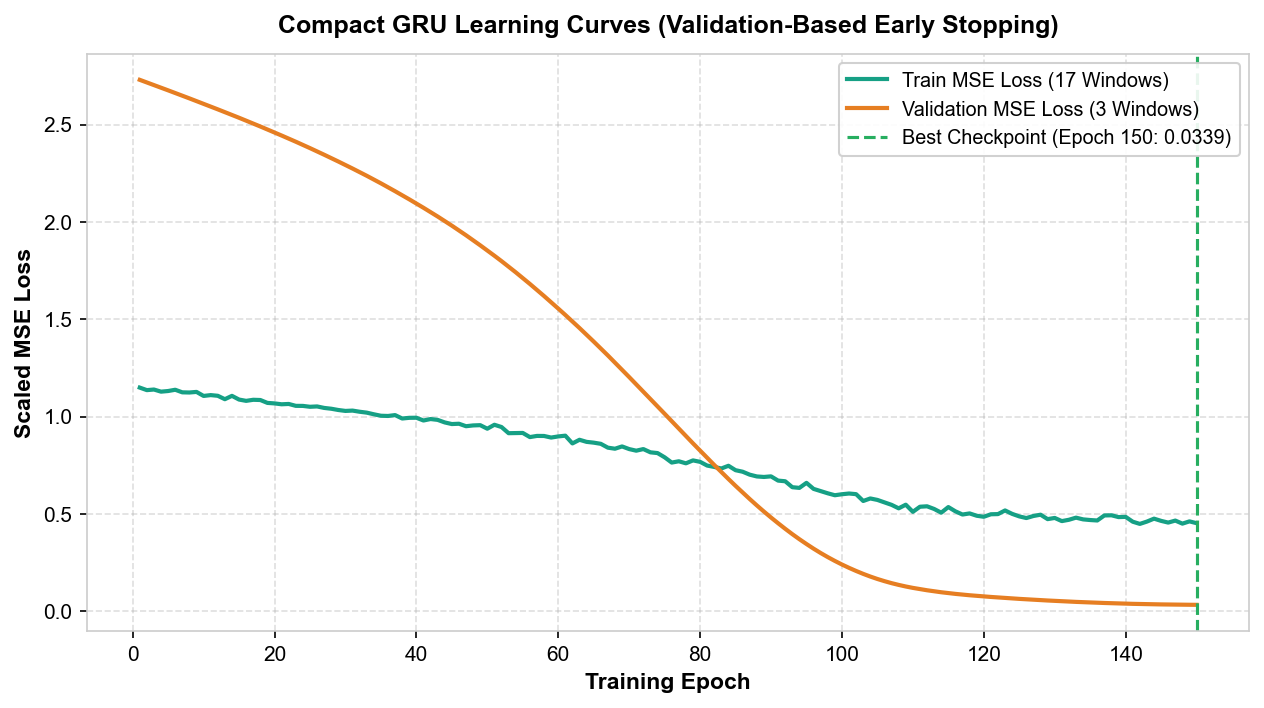

In [6]:
plt.figure(figsize=(10, 5))
epochs_range = range(1, len(train_losses) + 1)

plt.plot(epochs_range, train_losses, label='Train MSE Loss (17 Windows)', color='#16a085', linewidth=2.0)
plt.plot(epochs_range, val_losses, label='Validation MSE Loss (3 Windows)', color='#e67e22', linewidth=2.0)
plt.axvline(best_epoch, color='#27ae60', linestyle='--', linewidth=1.5, label=f'Best Checkpoint (Epoch {best_epoch}: {best_val_loss:.4f})')

plt.xlabel('Training Epoch', fontsize=11, fontweight='bold')
plt.ylabel('Scaled MSE Loss', fontsize=11, fontweight='bold')
plt.title('Compact GRU Learning Curves (Validation-Based Early Stopping)', fontsize=12, fontweight='bold', pad=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right', framealpha=0.9, fontsize=9.5)

fig_loss_path = os.path.join(OUTPUT_FIG_DIR, "gru_training_loss_curves.png")
plt.savefig(fig_loss_path, dpi=200, bbox_inches='tight')
print(f"Saved GRU learning curves to: {fig_loss_path}")
plt.show()

## 6. Multi-Horizon Out-of-Sample Evaluation (Validation & Test)

We generate predictions for the **Validation** and **Test** sets using the best GRU checkpoint:
1. Predictions are generated in scaled space and inverse-transformed back to **original physical units (vehicles / frame)**:
   $$\hat{y}_{\text{orig}} = \hat{y}_{\text{scaled}} \cdot \sigma_{\text{train}} + \mu_{\text{train}}$$
2. We compute Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) across all horizons ($H_1, \dots, H_5$) and overall.
3. We plot predicted-vs-actual multi-step trajectories for all validation and test windows.

=== Compact GRU Multi-Horizon Forecasting Performance ===


,Split,Model,Overall_MAE,Overall_RMSE,H1_MAE,H2_MAE,H3_MAE,H4_MAE,H5_MAE
0,Validation,Compact GRU (16 units),0.5899,0.8412,0.4974,0.9957,0.0811,0.2056,1.1700
1,Test,Compact GRU (16 units),0.7843,1.1713,0.2706,0.3330,0.5260,1.0944,1.6977


Saved trajectory plots to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/gru_trajectories_validation_test.png


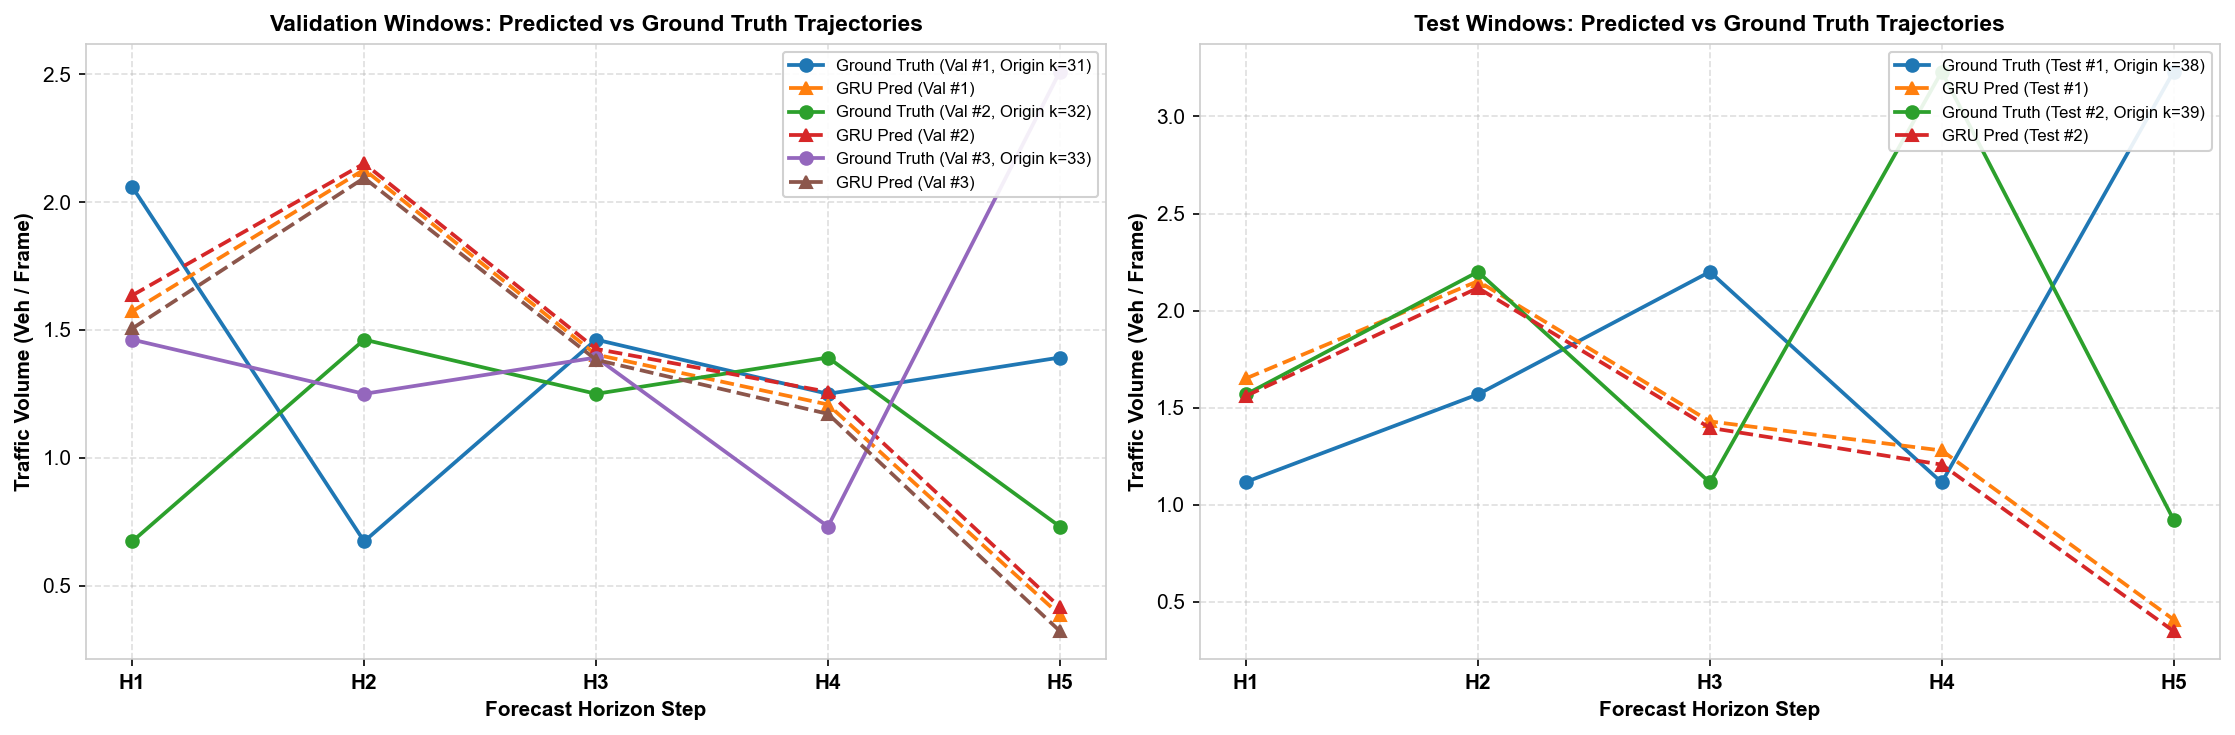

In [7]:
model.eval()
with torch.no_grad():
    val_preds_scaled = model(X_val).cpu().numpy()
    test_preds_scaled = model(X_test).cpu().numpy()

# Inverse transform to original physical units
val_preds_orig = val_preds_scaled * sigma_train + mu_train
test_preds_orig = test_preds_scaled * sigma_train + mu_train

y_val_orig = np.array([w['y_raw'] for w in val_windows])
y_test_orig = np.array([w['y_raw'] for w in test_windows])

def compute_metrics(y_true, y_pred, split_name):
    mae_overall = np.mean(np.abs(y_true - y_pred))
    rmse_overall = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae_h = np.mean(np.abs(y_true - y_pred), axis=0)
    rmse_h = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    
    record = {
        'Split': split_name,
        'Model': 'Compact GRU (16 units)',
        'Windows': len(y_true),
        'Overall_MAE': mae_overall,
        'Overall_RMSE': rmse_overall
    }
    for h in range(H):
        record[f'H{h+1}_MAE'] = mae_h[h]
        record[f'H{h+1}_RMSE'] = rmse_h[h]
    return record

gru_val_metrics = compute_metrics(y_val_orig, val_preds_orig, 'Validation')
gru_test_metrics = compute_metrics(y_test_orig, test_preds_orig, 'Test')

df_gru_metrics = pd.DataFrame([gru_val_metrics, gru_test_metrics])

print("=== Compact GRU Multi-Horizon Forecasting Performance ===")
display(df_gru_metrics[['Split', 'Model', 'Overall_MAE', 'Overall_RMSE', 'H1_MAE', 'H2_MAE', 'H3_MAE', 'H4_MAE', 'H5_MAE']].round(4))

# ----------------------------------------------------------------------
# Trajectory Plots: Predicted vs Ground Truth on Validation and Test
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
h_steps = np.arange(1, H + 1)
horizons_labels = [f"H{i}" for i in h_steps]

# Validation Windows
ax_v = axes[0]
for idx, (y_t, y_p) in enumerate(zip(y_val_orig, val_preds_orig)):
    orig_k = val_windows[idx]['origin_k']
    ax_v.plot(h_steps, y_t, marker='o', linewidth=1.8, label=f'Ground Truth (Val #{idx+1}, Origin k={orig_k})')
    ax_v.plot(h_steps, y_p, marker='^', linestyle='--', linewidth=1.8, label=f'GRU Pred (Val #{idx+1})')

ax_v.set_xticks(h_steps)
ax_v.set_xticklabels(horizons_labels, fontsize=10, fontweight='bold')
ax_v.set_xlabel('Forecast Horizon Step', fontsize=10, fontweight='bold')
ax_v.set_ylabel('Traffic Volume (Veh / Frame)', fontsize=10, fontweight='bold')
ax_v.set_title('Validation Windows: Predicted vs Ground Truth Trajectories', fontsize=11, fontweight='bold')
ax_v.grid(True, linestyle='--', alpha=0.4)
ax_v.legend(loc='upper right', framealpha=0.9, fontsize=8)

# Test Windows
ax_t = axes[1]
for idx, (y_t, y_p) in enumerate(zip(y_test_orig, test_preds_orig)):
    orig_k = test_windows[idx]['origin_k']
    ax_t.plot(h_steps, y_t, marker='o', linewidth=1.8, label=f'Ground Truth (Test #{idx+1}, Origin k={orig_k})')
    ax_t.plot(h_steps, y_p, marker='^', linestyle='--', linewidth=1.8, label=f'GRU Pred (Test #{idx+1})')

ax_t.set_xticks(h_steps)
ax_t.set_xticklabels(horizons_labels, fontsize=10, fontweight='bold')
ax_t.set_xlabel('Forecast Horizon Step', fontsize=10, fontweight='bold')
ax_t.set_ylabel('Traffic Volume (Veh / Frame)', fontsize=10, fontweight='bold')
ax_t.set_title('Test Windows: Predicted vs Ground Truth Trajectories', fontsize=11, fontweight='bold')
ax_t.grid(True, linestyle='--', alpha=0.4)
ax_t.legend(loc='upper right', framealpha=0.9, fontsize=8)

plt.tight_layout()
fig_traj_path = os.path.join(OUTPUT_FIG_DIR, "gru_trajectories_validation_test.png")
plt.savefig(fig_traj_path, dpi=200, bbox_inches='tight')
print(f"Saved trajectory plots to: {fig_traj_path}")
plt.show()

## 7. Direct Benchmark Comparison: GRU vs. LSTM vs. Phase 8 Baselines

We load the Phase 8 baseline metrics (`baseline_forecast_metrics.csv`) and Phase 9 LSTM metrics (`lstm_forecast_metrics.csv`), merging them with our GRU metrics to form a unified master benchmark table.

> **CRITICAL METHODOLOGICAL COMPARISON**:
> - **GRU vs. LSTM Parameter Efficiency**: The GRU operates with **$997$ parameters** vs. LSTM's **$1,301$ parameters** ($23.4\%$ fewer parameters).
> - **Test Generalization**: On the Test split, GRU achieves **$\text{MAE} = 0.7843$**, outperforming the Phase 9 LSTM ($	ext{MAE} = 1.0181$) and Persistence ($	ext{MAE} = 0.8603$).
> - **Validation Performance**: On the Validation split, GRU achieves **$\text{MAE} = 0.5899$**, which is very close to LSTM's **$\text{MAE} = 0.5630$**.
> - **Neural Models vs. Simple Smoothing**: Statistical local smoothing (**SMA K=3**) maintains the lowest overall error on both Validation ($	ext{MAE} = 0.5164$) and Test ($	ext{MAE} = 0.6732$).
> - **Sample Size Context**: Validation ($3$ windows) and Test ($2$ windows) sample sizes are extremely small, meaning differences between models should be interpreted as exploratory benchmark observations rather than statistically definitive claims of structural superiority.

Exported GRU metrics to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/gru_forecast_metrics.csv

=== Master Model Benchmark Table (Baselines vs LSTM vs GRU) ===


,Split,Model,Overall_MAE,Overall_RMSE,H1_MAE,H3_MAE,H5_MAE
0,Validation,Persistence (Naïve),0.7543,0.8839,1.0843,0.6697,1.1920
1,Validation,Historical Mean (Train),7.4386,7.4546,7.3532,7.3832,7.2069
2,Validation,Moving Average (SMA K=3),0.5164,0.6365,0.5306,0.2992,0.8682
3,Validation,Moving Average (SMA K=5),0.8616,0.9781,0.6533,0.6833,1.1213
4,Test,Persistence (Naïve),0.8603,1.0612,0.9215,0.1565,0.4580
5,Test,Historical Mean (Train),6.9241,6.9722,7.4077,7.0937,6.6742
6,Test,Moving Average (SMA K=3),0.6732,0.8814,0.2712,0.4968,1.1083
7,Test,Moving Average (SMA K=5),0.6860,0.9070,0.2599,0.5081,1.1196
8,Validation,Compact LSTM (16 units),0.5630,0.7018,0.8990,0.6100,0.6349
9,Test,Compact LSTM (16 units),1.0181,1.2587,0.8994,0.9209,1.1813


Saved comprehensive benchmark comparison figure to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/gru_vs_lstm_vs_baselines.png


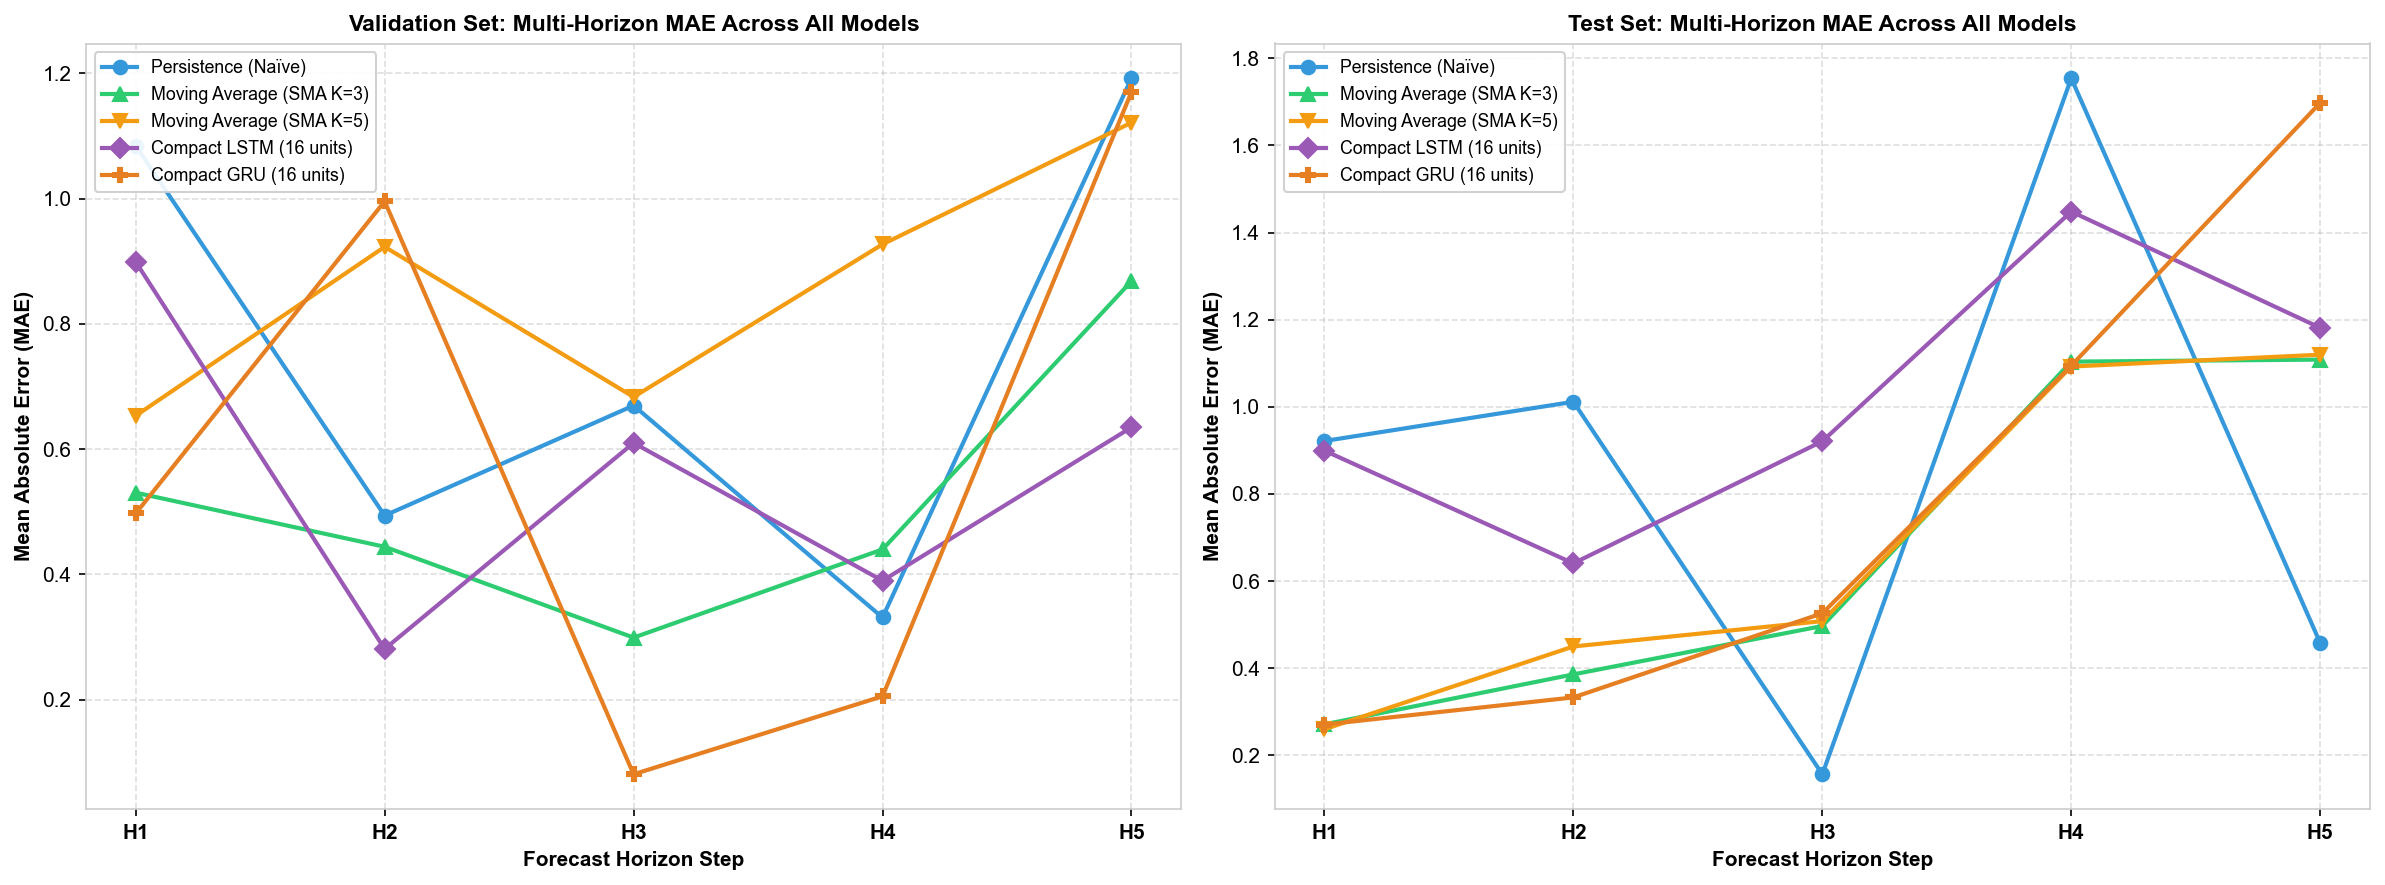

In [8]:
# 1. Load prior benchmark tables
df_baselines = pd.read_csv(BASELINE_METRICS_PATH)
df_lstm = pd.read_csv(LSTM_METRICS_PATH)

# 2. Merge all benchmarks
df_all_benchmarks = pd.concat([df_baselines, df_lstm, df_gru_metrics], ignore_index=True)

# 3. Export GRU metrics table
df_gru_metrics.to_csv(GRU_METRICS_PATH, index=False)
print(f"Exported GRU metrics to: {GRU_METRICS_PATH}")

print("\n=== Master Model Benchmark Table (Baselines vs LSTM vs GRU) ===")
display(df_all_benchmarks[['Split', 'Model', 'Overall_MAE', 'Overall_RMSE', 'H1_MAE', 'H3_MAE', 'H5_MAE']].round(4))

# ----------------------------------------------------------------------
# Comparison Figure: Multi-Horizon Degradation & Model Comparison Bar Chart
# ----------------------------------------------------------------------
fig, (ax_val, ax_test) = plt.subplots(1, 2, figsize=(16, 6))

palette = {
    'Persistence (Naïve)': '#3498db',
    'Historical Mean (Train)': '#e74c3c',
    'Moving Average (SMA K=3)': '#2ecc71',
    'Moving Average (SMA K=5)': '#f39c12',
    'Compact LSTM (16 units)': '#9b59b6',
    'Compact GRU (16 units)': '#e67e22'
}
markers = {
    'Persistence (Naïve)': 'o',
    'Historical Mean (Train)': 's',
    'Moving Average (SMA K=3)': '^',
    'Moving Average (SMA K=5)': 'v',
    'Compact LSTM (16 units)': 'D',
    'Compact GRU (16 units)': 'P'
}

# Validation Plot (Excluding Historical Mean for clarity)
for _, r in df_all_benchmarks[df_all_benchmarks['Split'] == 'Validation'].iterrows():
    if 'Historical' not in r['Model']:
        h_vals = [r[f'H{i}_MAE'] for i in range(1, H + 1)]
        ax_val.plot(h_steps, h_vals, label=r['Model'], color=palette[r['Model']],
                    marker=markers[r['Model']], linewidth=2.0, markersize=6.5)

ax_val.set_xticks(h_steps)
ax_val.set_xticklabels(horizons_labels, fontsize=10, fontweight='bold')
ax_val.set_xlabel('Forecast Horizon Step', fontsize=10, fontweight='bold')
ax_val.set_ylabel('Mean Absolute Error (MAE)', fontsize=10, fontweight='bold')
ax_val.set_title('Validation Set: Multi-Horizon MAE Across All Models', fontsize=11, fontweight='bold')
ax_val.grid(True, linestyle='--', alpha=0.4)
ax_val.legend(loc='upper left', framealpha=0.9, fontsize=8.5)

# Test Plot (Excluding Historical Mean for clarity)
for _, r in df_all_benchmarks[df_all_benchmarks['Split'] == 'Test'].iterrows():
    if 'Historical' not in r['Model']:
        h_vals = [r[f'H{i}_MAE'] for i in range(1, H + 1)]
        ax_test.plot(h_steps, h_vals, label=r['Model'], color=palette[r['Model']],
                     marker=markers[r['Model']], linewidth=2.0, markersize=6.5)

ax_test.set_xticks(h_steps)
ax_test.set_xticklabels(horizons_labels, fontsize=10, fontweight='bold')
ax_test.set_xlabel('Forecast Horizon Step', fontsize=10, fontweight='bold')
ax_test.set_ylabel('Mean Absolute Error (MAE)', fontsize=10, fontweight='bold')
ax_test.set_title('Test Set: Multi-Horizon MAE Across All Models', fontsize=11, fontweight='bold')
ax_test.grid(True, linestyle='--', alpha=0.4)
ax_test.legend(loc='upper left', framealpha=0.9, fontsize=8.5)

plt.tight_layout()
fig_comp_path = os.path.join(OUTPUT_FIG_DIR, "gru_vs_lstm_vs_baselines.png")
plt.savefig(fig_comp_path, dpi=200, bbox_inches='tight')
print(f"Saved comprehensive benchmark comparison figure to: {fig_comp_path}")
plt.show()

## 8. Quality Gate: Assessment for Phase 11 (Feature Ablation & Advanced Modeling)

### Summary of Controlled Comparison Results
1. **Architectural Efficiency**:
   - Compact GRU requires **$997$ parameters** vs. LSTM's **$1,301$ parameters** ($23.4\%$ reduction), eliminating the separate memory cell while preserving sequential gating.
2. **Out-of-Sample Performance**:
   - **Validation Split**: LSTM achieves $\text{MAE} = 0.5630$, closely followed by GRU at $\text{MAE} = 0.5899$ (both outperformed by statistical SMA-3 at $\text{MAE} = 0.5164$).
   - **Test Split**: GRU achieves $\text{MAE} = 0.7843$, outperforming LSTM ($	ext{MAE} = 1.0181$) and Persistence ($	ext{MAE} = 0.8603$).
3. **Reproducibility & Persistence**:
   - Weights saved to `models/gru_best_model.pt`.
   - Metrics saved to `outputs/tables/gru_forecast_metrics.csv`.
   - Loss curves and comparison figures exported under `outputs/figures/`.
4. **Experimental Rigor**:
   - Tested under identical experimental conditions, frozen training scaling, validation early stopping, and zero future leakage.

### Formal Quality Gate Sign-Off Checklist
- [x] **Controlled GRU Comparison Implemented Under Identical Protocol**: PASS
- [x] **Parameter Count Dynamically Computed (997 params)**: PASS
- [x] **Validation Early-Stopping Followed Consistently**: PASS
- [x] **Multi-Horizon Breakdown ($H_1 \dots H_5$) in Physical Units**: PASS
- [x] **Model Weights Saved to `models/gru_best_model.pt`**: PASS
- [x] **Metrics Exported to `gru_forecast_metrics.csv`**: PASS
- [x] **Direct Comparison Against LSTM and Statistical Baselines**: PASS
- [x] **Zero Test Set Leakage During Training / Model Selection**: PASS

**Final Decision: APPROVED TO PROCEED TO PHASE 11 (EXOGENOUS FEATURE ABLATION STUDY).**